# Tanager hyperspectral vs. Landsat multispectral cho đảo nhiệt đô thị

Notebook này chạy một benchmark có kiểm soát trên TP.HCM–Thủ Đức:

1. **HSI-full:** phổ phản xạ Tanager, giữ các band tốt ngoài vùng hấp thụ khí quyển.
2. **MSI-sim:** tích phân chính phổ Tanager bằng Relative Spectral Response (RSR) của Landsat 8 OLI.
3. **Nhiệt độ mục tiêu:** Landsat 8 Collection 2 Level-2 `ST_B10`, chụp sau Tanager 2 ngày.

Thiết kế HSI-full/MSI-sim giữ nguyên thời điểm, pixel và khí quyển, nên so sánh tập trung vào lượng thông tin phổ. Phần vật liệu là thử nghiệm thăm dò vì hiện chưa có ground truth vật liệu mái/bề mặt độc lập.

## 0. Cấu hình

Thông số pilot mặc định ưu tiên chạy được trên máy cá nhân. Để tạo kết quả cuối, tăng `PPI_PROJECTIONS` từ 2.000 lên 10.000 và có thể tăng `TRAIN_SAMPLES`.

In [1]:
from pathlib import Path
import json, warnings, time

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
from skimage.segmentation import slic

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.random.seed(42)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

TANAGER_DIR = ROOT / "data" / "tanager"
LANDSAT_DIR = ROOT / "data" / "landsat"
RSR_FILE = ROOT / "data" / "rsr" / "L8_OLI_RSR.xlsx"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

H5_FILE = TANAGER_DIR / "20250407_035451_00_4001_ortho_sr_hdf5.h5"
RGB_FILE = TANAGER_DIR / "20250407_035451_00_4001_ortho_visual.tif"
UDM_FILE = TANAGER_DIR / "20250407_035451_00_4001_ortho_beta_udm.tif"
STAC_FILE = TANAGER_DIR / "20250407_035451_00_4001.json"

N_MNF = 16
N_ENDMEMBERS = 7
TRAIN_SAMPLES = 60_000
NOISE_SAMPLES = 40_000
PPI_SAMPLES = 20_000
PPI_PROJECTIONS = 2_000       # đổi thành 10_000 cho lần chạy cuối
PURE_FRACTION = 0.005         # 0,5% pixel có PPI cao nhất
FCLS_ITERATIONS = 60
SPATIAL_BLOCK_M = 1_000
MAX_BENCHMARK_PIXELS = 120_000

for p in [H5_FILE, RGB_FILE, UDM_FILE, STAC_FILE, RSR_FILE]:
    assert p.exists(), f"Thiếu file: {p}"
print("Project root:", ROOT)

Project root: .


## 1. Kiểm kê dữ liệu và lưới không gian

,file,size_MB
0,data/README.md,0.00
1,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,0.01
2,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,3.54
3,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,0.22
4,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,85.89
5,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,86.39
6,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,88.80
7,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,92.24
8,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,92.71
9,data/landsat/LC08_L2SP_125052_20250409_02_T1/L...,91.81


Tanager bbox: [106.59595359085495, 10.74422514543046, 106.81856896212841, 10.932700725032094]
Grid: 809 x 691 | EPSG:32648 | | 30.00, 0.00, 674490.00|
| 0.00,-30.00, 1209000.00|
| 0.00, 0.00, 1.00|


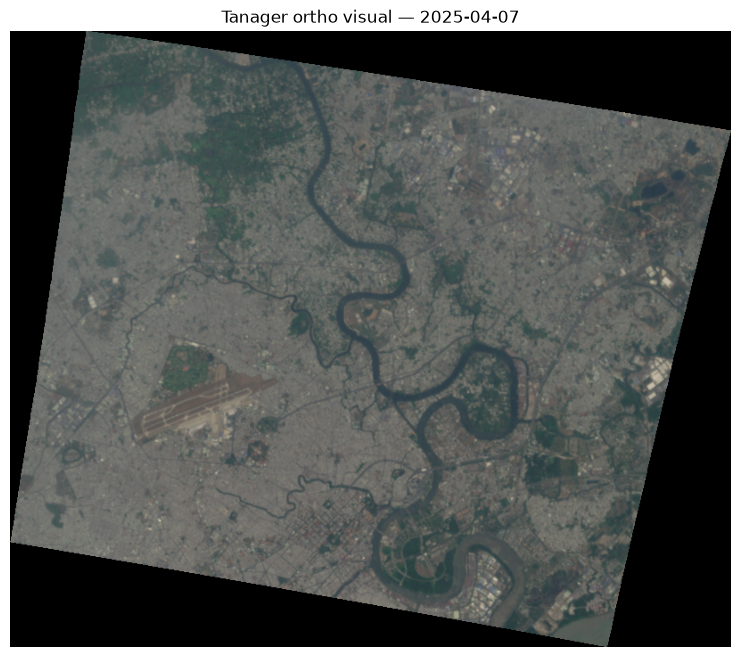

In [2]:
inventory = []
for p in sorted((ROOT / "data").rglob("*")):
    if p.is_file():
        inventory.append({"file": str(p.relative_to(ROOT)), "size_MB": p.stat().st_size / 2**20})
display(pd.DataFrame(inventory).round(2))

with rasterio.open(RGB_FILE) as src:
    target_profile = src.profile.copy()
    target_transform = src.transform
    target_crs = src.crs
    height, width = src.height, src.width
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0)

with open(STAC_FILE) as f:
    tanager_stac = json.load(f)

print("Tanager bbox:", tanager_stac["bbox"])
print("Grid:", width, "x", height, "|", target_crs, "|", target_transform)
plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.title("Tanager ortho visual — 2025-04-07")
plt.axis("off");

## 2. Đọc hyperspectral và tạo quality mask

Giữ các band được nhà sản xuất đánh dấu tốt trong ba cửa sổ: `400–1340`, `1490–1770`, `2050–2450 nm`. Các vùng hấp thụ khí quyển quanh 1.4 và 1.9 µm bị loại.

In [3]:
FIELDS = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(H5_FILE, "r") as h5:
    sr_ds = h5[f"{FIELDS}/surface_reflectance"]
    sr_shape = sr_ds.shape
    wavelengths = sr_ds.attrs["wavelengths"].astype(float)
    fwhm = sr_ds.attrs["fwhm"].astype(float)
    good_native = sr_ds.attrs["good_wavelengths"].astype(bool)
    nodata = h5[f"{FIELDS}/nodata_pixels"][:]
    cloud = h5[f"{FIELDS}/beta_cloud_mask"][:]
    cirrus = h5[f"{FIELDS}/beta_cirrus_mask"][:]
    aod = h5[f"{FIELDS}/aerosol_optical_depth"][:]

spectral_windows = (
    ((wavelengths >= 400) & (wavelengths <= 1340)) |
    ((wavelengths >= 1490) & (wavelengths <= 1770)) |
    ((wavelengths >= 2050) & (wavelengths <= 2450))
)
usable = good_native & spectral_windows
usable_idx = np.flatnonzero(usable)
wl = wavelengths[usable]

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0) & np.isfinite(aod) & (aod != -9999)
print("HDF5 shape:", sr_shape)
print("Band giữ lại:", usable.sum(), "/", len(wavelengths))
print("Pixel valid ban đầu:", f"{valid.mean():.1%}")
print("Mask values — nodata/cloud/cirrus:", np.unique(nodata), np.unique(cloud), np.unique(cirrus))

# ~700 MB; đủ cho toàn bộ pipeline nhưng vẫn nhỏ hơn việc nhân bản cube 426-band.
with h5py.File(H5_FILE, "r") as h5:
    cube = h5[f"{FIELDS}/surface_reflectance"][usable_idx, :, :].astype(np.float32)

valid &= np.isfinite(cube).all(axis=0) & (cube > -1).all(axis=0)
cube[:, ~valid] = np.nan
print("Pixel valid sau kiểm tra reflectance:", f"{valid.mean():.1%}")

HDF5 shape: (426, 691, 809)
Band giữ lại: 325 / 426
Pixel valid ban đầu: 62.1%
Mask values — nodata/cloud/cirrus: [0 1] [0 1] [0 1]


Pixel valid sau kiểm tra reflectance: 62.1%


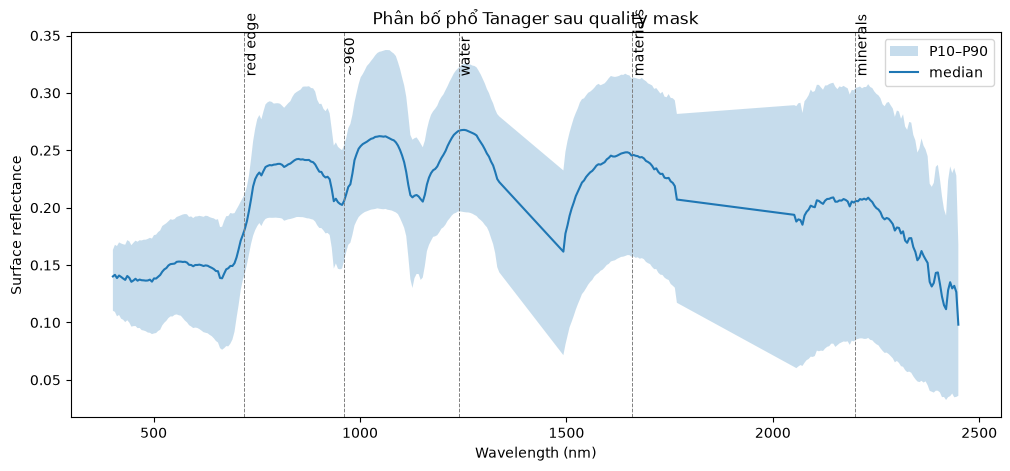

In [4]:
def nearest_band(target_nm):
    return int(np.argmin(np.abs(wl - target_nm)))

fig, ax = plt.subplots(figsize=(12, 5))
rr, cc = np.where(valid)
take = np.random.default_rng(42).choice(len(rr), size=min(1500, len(rr)), replace=False)
spectra_preview = cube[:, rr[take], cc[take]].T
q10, q50, q90 = np.nanpercentile(spectra_preview, [10, 50, 90], axis=0)
ax.fill_between(wl, q10, q90, alpha=.25, label="P10–P90")
ax.plot(wl, q50, lw=1.5, label="median")
for x, label in [(720,"red edge"), (960,"~960"), (1240,"water"), (1660,"materials"), (2200,"minerals")]:
    ax.axvline(x, ls="--", lw=.7, color="grey"); ax.text(x, ax.get_ylim()[1]*.9, label, rotation=90)
ax.set(xlabel="Wavelength (nm)", ylabel="Surface reflectance", title="Phân bố phổ Tanager sau quality mask")
ax.legend();

## 3. Giả lập Landsat OLI từ Tanager

RSR lấy từ USGS. Mỗi band được tính bằng tích phân có trọng số trên đúng các bước sóng Tanager. Ta dùng B2–B7 vì chúng nằm trong miền phổ của Tanager và phục vụ NDVI/NDBI/MNDWI.

./.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
./.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
./.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
./.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
./.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
./.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,band,sheet,effective_nm
0,B2,Blue,483.04
1,B3,Green,561.34
2,B4,Red,654.62
3,B5,NIR,864.58
4,B6,SWIR1,1609.11
5,B7,SWIR2,2201.28


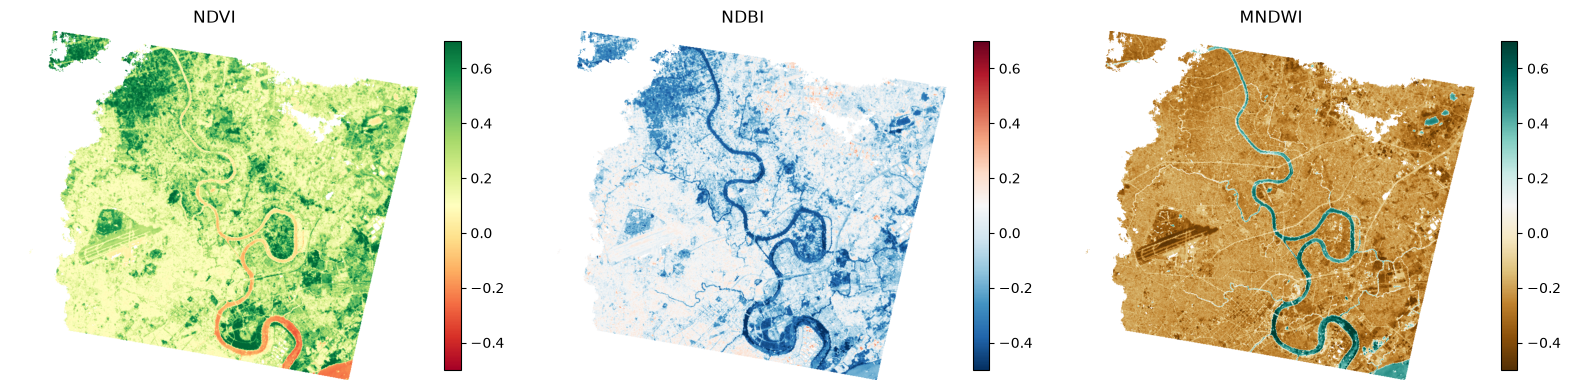

In [5]:
sheet_map = {"B2":"Blue", "B3":"Green", "B4":"Red", "B5":"NIR", "B6":"SWIR1", "B7":"SWIR2"}
rsr_weights = []
rsr_rows = []
for band, sheet in sheet_map.items():
    frame = pd.read_excel(RSR_FILE, sheet_name=sheet)
    x = pd.to_numeric(frame.iloc[:, 0], errors="coerce").to_numpy()
    y = pd.to_numeric(frame.iloc[:, 1], errors="coerce").to_numpy()
    ok = np.isfinite(x) & np.isfinite(y)
    response = np.interp(wl, x[ok], y[ok], left=0, right=0)
    response[response < 0] = 0
    response /= response.sum()
    rsr_weights.append(response)
    rsr_rows.append({"band":band, "sheet":sheet, "effective_nm":float((response*wl).sum())})
rsr_weights = np.asarray(rsr_weights, dtype=np.float32)
band_names = list(sheet_map)
display(pd.DataFrame(rsr_rows).round(2))

# Matrix multiplication theo từng chunk hàng để không tạo thêm bản sao cube lớn.
msi = np.full((len(band_names), height, width), np.nan, np.float32)
for r0 in range(0, height, 64):
    r1 = min(r0 + 64, height)
    block = cube[:, r0:r1, :]
    msi[:, r0:r1, :] = np.tensordot(rsr_weights, block, axes=(1, 0))

B2, B3, B4, B5, B6, B7 = msi
safe_ratio = lambda a, b: np.divide(a-b, a+b, out=np.full_like(a, np.nan), where=np.abs(a+b)>1e-6)
ndvi = safe_ratio(B5, B4)
ndbi = safe_ratio(B6, B5)
mndwi = safe_ratio(B3, B6)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, img, name, cmap in zip(axes, [ndvi, ndbi, mndwi], ["NDVI", "NDBI", "MNDWI"], ["RdYlGn", "RdBu_r", "BrBG"]):
    im=ax.imshow(img, cmap=cmap, vmin=-.5, vmax=.7); ax.set_title(name); ax.axis("off"); plt.colorbar(im, ax=ax, shrink=.7)
plt.tight_layout();

## 4. MNF: noise whitening + PCA

Noise được ước lượng từ sai phân hai pixel kề nhau. Sau whitening theo covariance của noise, PCA được chạy trên mẫu 60.000 pixel. Giữ 16 thành phần đầu.

MNF hoàn tất sau 0.3s


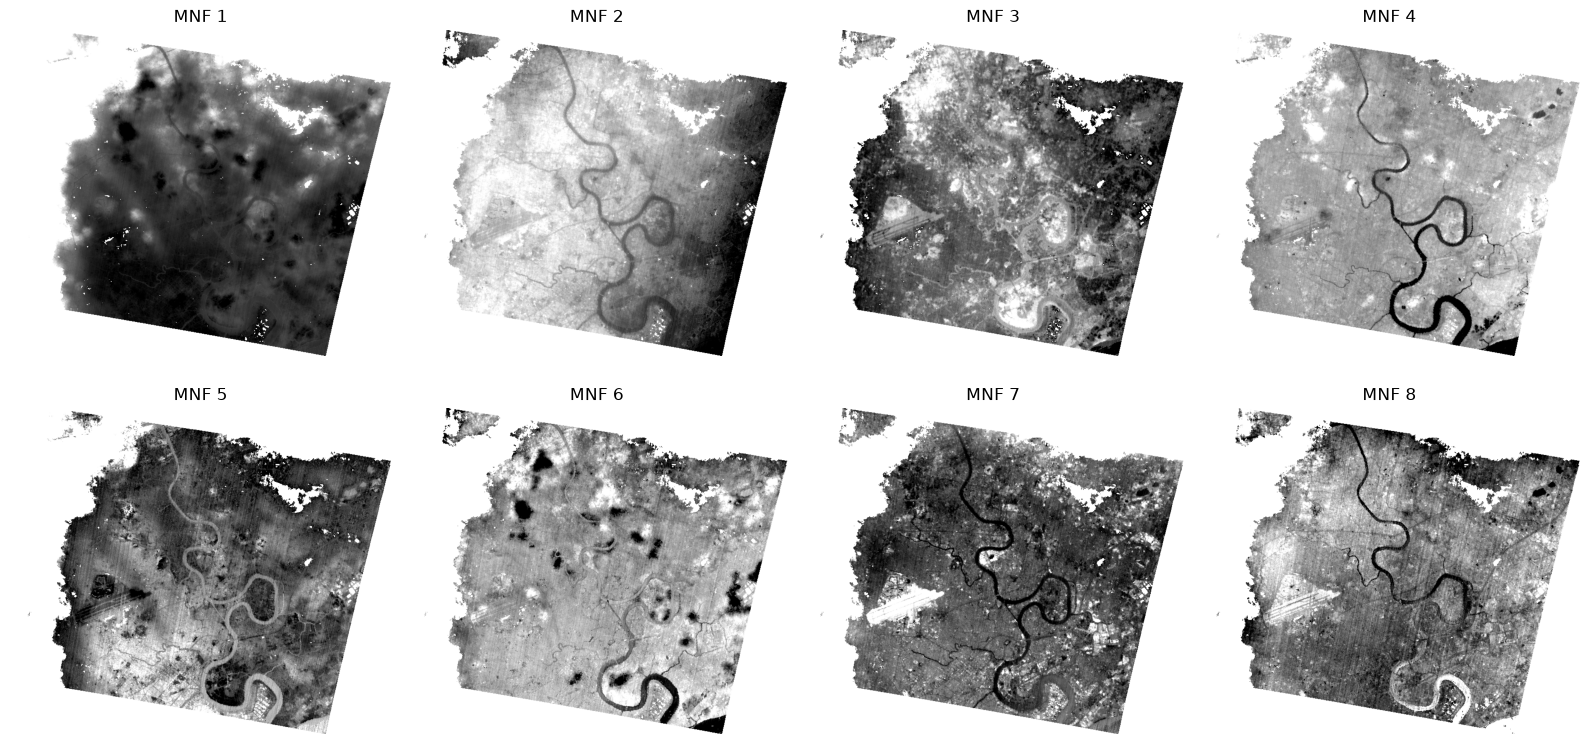

In [6]:
rng = np.random.default_rng(42)
rr, cc = np.where(valid)
n_train = min(TRAIN_SAMPLES, len(rr))
sel = rng.choice(len(rr), n_train, replace=False)
X_train = cube[:, rr[sel], cc[sel]].T.astype(np.float64)

pair_mask = valid[:, :-1] & valid[:, 1:]
pr, pc = np.where(pair_mask)
n_noise = min(NOISE_SAMPLES, len(pr))
ps = rng.choice(len(pr), n_noise, replace=False)
noise_diff = (cube[:, pr[ps], pc[ps]] - cube[:, pr[ps], pc[ps]+1]).T.astype(np.float64)

def fit_mnf(X, differences, n_components=16):
    mean = X.mean(axis=0)
    noise_cov = np.cov(differences, rowvar=False) / 2
    reg = max(np.trace(noise_cov) / noise_cov.shape[0] * 1e-5, 1e-10)
    nv, ne = np.linalg.eigh(noise_cov + reg*np.eye(noise_cov.shape[0]))
    whitener = (ne * (1/np.sqrt(np.maximum(nv, reg)))) @ ne.T
    Z = (X - mean) @ whitener
    sv, se = np.linalg.eigh(np.cov(Z, rowvar=False))
    order = np.argsort(sv)[::-1]
    components = whitener @ se[:, order[:n_components]]
    return mean, components, sv[order]

t0=time.time()
mnf_mean, mnf_components, mnf_eigenvalues = fit_mnf(X_train, noise_diff, N_MNF)
mnf_map = np.full((N_MNF, height, width), np.nan, np.float32)
for r0 in range(0, height, 64):
    r1=min(r0+64, height)
    X=cube[:,r0:r1,:].reshape(len(wl),-1).T
    ok=np.isfinite(X).all(axis=1)
    scores=np.full((X.shape[0],N_MNF),np.nan,np.float32)
    scores[ok]=((X[ok]-mnf_mean)@mnf_components).astype(np.float32)
    mnf_map[:,r0:r1,:]=scores.T.reshape(N_MNF,r1-r0,width)
print(f"MNF hoàn tất sau {time.time()-t0:.1f}s")

fig, axes=plt.subplots(2,4,figsize=(16,8))
for i,ax in enumerate(axes.ravel()):
    lo,hi=np.nanpercentile(mnf_map[i],[2,98]); ax.imshow(mnf_map[i],cmap="gray",vmin=lo,vmax=hi); ax.set_title(f"MNF {i+1}"); ax.axis("off")
plt.tight_layout();

## 5. PPI, endmember và kiểm tra phổ

PPI chiếu mẫu MNF theo các hướng ngẫu nhiên, đếm số lần mỗi pixel nằm ở cực đại/cực tiểu. Top 0,5% được gom thành 7 endmember bằng K-means. Vì chưa có ground truth vật liệu, notebook gọi chúng là `E0…E6`; bảng chỉ số hỗ trợ đặt tên sau khi xem ảnh và phổ.

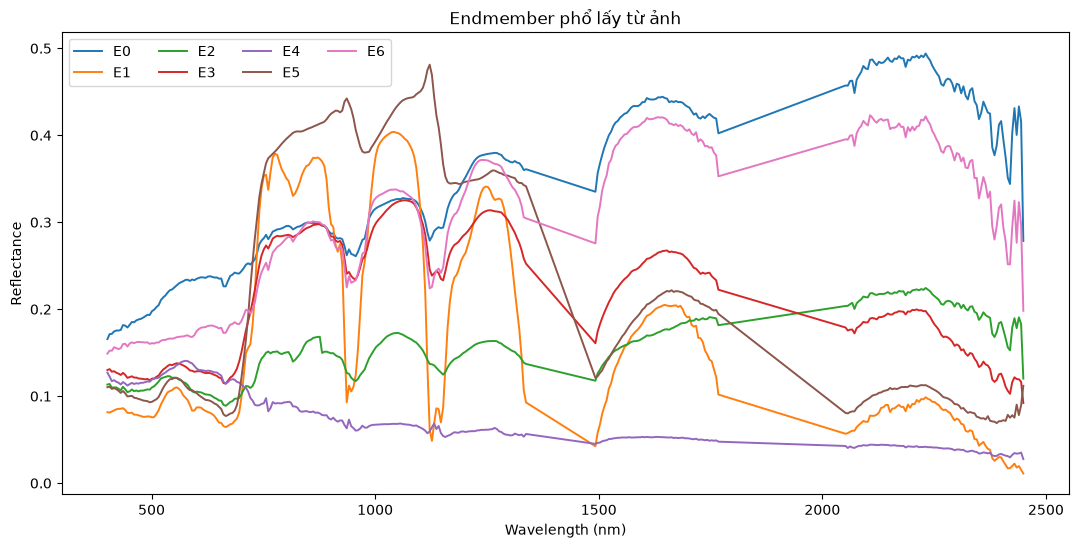

In [7]:
sample_n=min(PPI_SAMPLES,len(rr))
ppi_pick=rng.choice(len(rr),sample_n,replace=False)
ppi_rc=(rr[ppi_pick],cc[ppi_pick])
ppi_X=cube[:,ppi_rc[0],ppi_rc[1]].T
ppi_scores=(ppi_X-mnf_mean)@mnf_components
ppi_scores=(ppi_scores-ppi_scores.mean(0))/(ppi_scores.std(0)+1e-9)

def ppi_counts(scores,n_projections=2000,batch=128,seed=42):
    gen=np.random.default_rng(seed); counts=np.zeros(len(scores),np.int32)
    done=0
    while done<n_projections:
        n=min(batch,n_projections-done)
        directions=gen.normal(size=(scores.shape[1],n))
        directions/=np.linalg.norm(directions,axis=0,keepdims=True)
        projection=scores@directions
        np.add.at(counts,np.argmax(projection,axis=0),1)
        np.add.at(counts,np.argmin(projection,axis=0),1)
        done+=n
    return counts

counts=ppi_counts(ppi_scores,PPI_PROJECTIONS)
n_pure=max(N_ENDMEMBERS*5,int(np.ceil(PURE_FRACTION*sample_n)))
pure_local=np.argsort(counts)[-n_pure:]
kmeans=KMeans(n_clusters=N_ENDMEMBERS,n_init=30,random_state=42).fit(ppi_scores[pure_local,:10])
endmembers=np.vstack([ppi_X[pure_local][kmeans.labels_==k].mean(axis=0) for k in range(N_ENDMEMBERS)]).astype(np.float32)

fig,ax=plt.subplots(figsize=(13,6))
for k,e in enumerate(endmembers): ax.plot(wl,e,lw=1.4,label=f"E{k}")
ax.set(xlabel="Wavelength (nm)",ylabel="Reflectance",title="Endmember phổ lấy từ ảnh"); ax.legend(ncol=4);

In [8]:
# Tích phân các endmember sang OLI để diễn giải nhóm phổ.
em_msi=endmembers@rsr_weights.T
em_B2,em_B3,em_B4,em_B5,em_B6,em_B7=em_msi.T
em_table=pd.DataFrame({
    "endmember":[f"E{k}" for k in range(N_ENDMEMBERS)],
    "NDVI":(em_B5-em_B4)/(em_B5+em_B4+1e-9),
    "NDBI":(em_B6-em_B5)/(em_B6+em_B5+1e-9),
    "MNDWI":(em_B3-em_B6)/(em_B3+em_B6+1e-9),
    "R_960":endmembers[:,nearest_band(960)],
    "R_1660":endmembers[:,nearest_band(1660)],
    "R_2200":endmembers[:,nearest_band(2200)],
})
display(em_table.round(3).sort_values("NDVI"))

,endmember,NDVI,NDBI,MNDWI,R_960,R_1660,R_2200
4,E4,-0.200,-0.213,0.441,0.061,0.052,0.042
0,E0,0.124,0.190,-0.316,0.266,0.438,0.490
6,E6,0.257,0.161,-0.424,0.241,0.413,0.410
2,E2,0.278,0.007,-0.178,0.120,0.176,0.222
3,E3,0.424,-0.074,-0.309,0.239,0.266,0.199
5,E5,0.658,-0.339,-0.272,0.397,0.220,0.112
1,E1,0.684,-0.327,-0.296,0.153,0.204,0.091


## 6. FCLS và SAM

FCLS dùng projected gradient descent trên simplex: mọi fraction không âm và tổng bằng 1. SAM tạo lớp cứng bổ trợ. Kết quả gồm fraction, reconstruction RMSE, nhãn SAM và spectral angle nhỏ nhất.

Median reconstruction RMSE: 0.01364836934953928


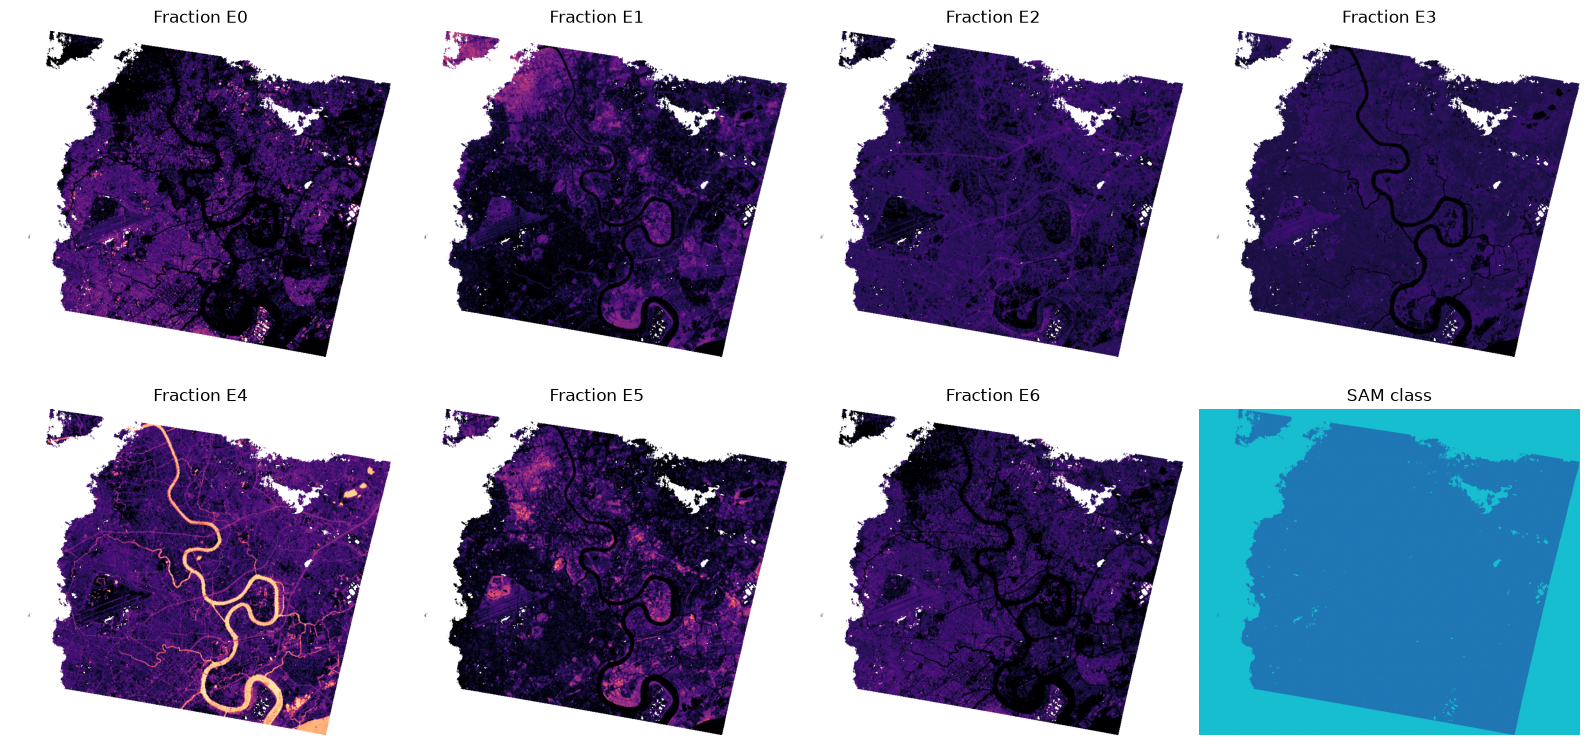

In [9]:
def project_simplex(V):
    U=np.sort(V,axis=1)[:,::-1]
    cssv=np.cumsum(U,axis=1)-1
    j=np.arange(1,V.shape[1]+1)
    rho=(U-cssv/j>0).sum(axis=1)-1
    theta=cssv[np.arange(len(V)),rho]/(rho+1)
    return np.maximum(V-theta[:,None],0)

G=endmembers@endmembers.T
step=0.95/np.linalg.norm(G,2)
fractions=np.full((N_ENDMEMBERS,height,width),np.nan,np.float32)
recon_rmse=np.full((height,width),np.nan,np.float32)
sam_class=np.full((height,width),255,np.uint8)
sam_angle=np.full((height,width),np.nan,np.float32)
En=endmembers/(np.linalg.norm(endmembers,axis=1,keepdims=True)+1e-9)

for r0 in range(0,height,48):
    r1=min(r0+48,height)
    X=cube[:,r0:r1,:].reshape(len(wl),-1).T
    ok=np.isfinite(X).all(axis=1)
    Xv=X[ok]
    C=Xv@endmembers.T
    F=np.full((len(Xv),N_ENDMEMBERS),1/N_ENDMEMBERS,np.float32)
    for _ in range(FCLS_ITERATIONS):
        F=project_simplex(F-step*(F@G-C)).astype(np.float32)
    pred=F@endmembers
    rmse=np.sqrt(np.mean((pred-Xv)**2,axis=1))
    cosine=(Xv@En.T)/(np.linalg.norm(Xv,axis=1,keepdims=True)+1e-9)
    angles=np.arccos(np.clip(cosine,-1,1))
    flat_n=(r1-r0)*width
    fb=np.full((flat_n,N_ENDMEMBERS),np.nan,np.float32); fb[ok]=F
    fractions[:,r0:r1,:]=fb.T.reshape(N_ENDMEMBERS,r1-r0,width)
    rb=np.full(flat_n,np.nan,np.float32); rb[ok]=rmse; recon_rmse[r0:r1]=rb.reshape(r1-r0,width)
    cb=np.full(flat_n,255,np.uint8); cb[ok]=np.argmin(angles,axis=1); sam_class[r0:r1]=cb.reshape(r1-r0,width)
    ab=np.full(flat_n,np.nan,np.float32); ab[ok]=np.min(angles,axis=1); sam_angle[r0:r1]=ab.reshape(r1-r0,width)

print("Median reconstruction RMSE:",float(np.nanmedian(recon_rmse)))
fig,axes=plt.subplots(2,4,figsize=(16,8))
for k,ax in enumerate(axes.ravel()[:N_ENDMEMBERS]):
    im=ax.imshow(fractions[k],vmin=0,vmax=1,cmap="magma"); ax.set_title(f"Fraction E{k}"); ax.axis("off")
axes.ravel()[-1].imshow(sam_class,cmap="tab10"); axes.ravel()[-1].set_title("SAM class"); axes.ravel()[-1].axis("off")
plt.tight_layout();

## 7. Baseline bốn lớp kiểu Brazil và object segmentation

SLIC tạo khoảng 1.200 object từ MSI-sim. Mỗi object được gán một trong bốn lớp: water, vegetation, urban, low-density/bare bằng trung bình NDVI/NDBI/MNDWI. Đây là baseline không giám sát; cần polygon độc lập nếu muốn báo cáo accuracy phân loại.

water                13477
vegetation           83776
urban               168765
low_density_bare     80881
Name: pixels, dtype: int64

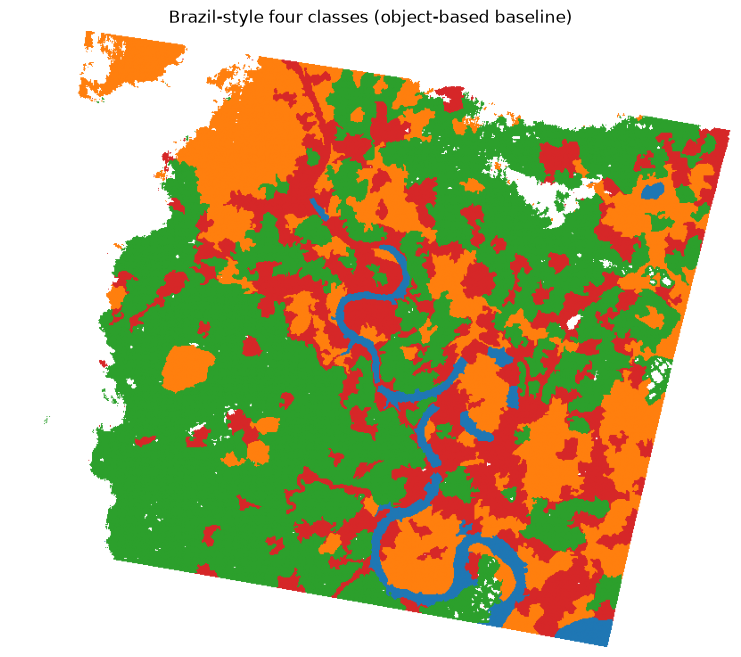

In [10]:
rgb_sim=np.stack([B4,B3,B2],axis=-1)
lo=np.nanpercentile(rgb_sim[valid],2,axis=0); hi=np.nanpercentile(rgb_sim[valid],98,axis=0)
rgb_scaled=np.clip((rgb_sim-lo)/(hi-lo+1e-9),0,1); rgb_scaled[~valid]=0
segments=slic(rgb_scaled,n_segments=1200,compactness=10,sigma=1,start_label=0,mask=valid,channel_axis=-1)

classes=np.full((height,width),255,np.uint8)
CLASS_NAMES={0:"water",1:"vegetation",2:"urban",3:"low_density_bare"}
for seg in np.unique(segments[valid]):
    m=(segments==seg)&valid
    vi,bi,wi=np.nanmean(ndvi[m]),np.nanmean(ndbi[m]),np.nanmean(mndwi[m])
    if wi>0.05 and wi>vi: cls=0
    elif vi>0.35: cls=1
    elif bi>0: cls=2
    else: cls=3
    classes[m]=cls

fig,ax=plt.subplots(figsize=(10,8)); im=ax.imshow(np.ma.masked_where(classes==255,classes),cmap="tab10",vmin=0,vmax=9)
ax.set_title("Brazil-style four classes (object-based baseline)"); ax.axis("off")
display(pd.Series({CLASS_NAMES[k]:int((classes==k).sum()) for k in CLASS_NAMES},name="pixels"))

## 8. Landsat LST: QA, scale và đồng đăng ký

`QA_PIXEL` loại fill, dilated cloud, cirrus, cloud, cloud shadow và snow. `QA_RADSAT` loại pixel bão hòa. Công thức Collection 2 Level-2: `K = DN × 0.00341802 + 149`; sau đó đổi sang °C. Hai rows được warp trực tiếp về lưới Tanager và lấy trung bình nơi chồng lấn.

LC08_L2SP_125052_20250409_02_T1 native valid 44.1%


LC08_L2SP_125053_20250409_02_T1 native valid 35.2%
Common valid Tanager + Landsat LST: 37.0% | pixels: 206870


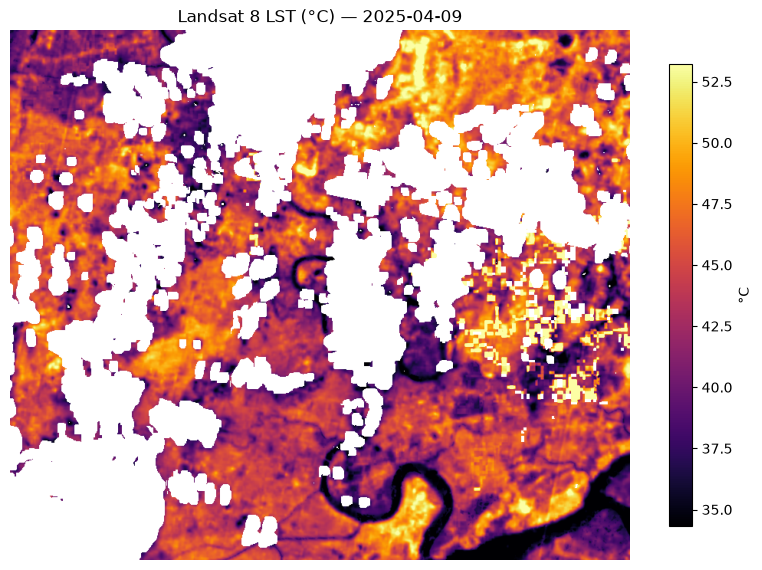

In [11]:
def find_one(folder, suffix):
    hits=list(folder.glob(f"*{suffix}"))
    if len(hits)!=1: raise FileNotFoundError(f"Cần đúng 1 file *{suffix} trong {folder}; tìm thấy {len(hits)}")
    return hits[0]

def warp_landsat_lst(folder):
    st_path=find_one(folder,"_ST_B10.TIF")
    qa_path=find_one(folder,"_QA_PIXEL.TIF")
    sat_path=find_one(folder,"_QA_RADSAT.TIF")
    with rasterio.open(st_path) as st_src, rasterio.open(qa_path) as qa_src, rasterio.open(sat_path) as sat_src:
        dn=st_src.read(1); qa=qa_src.read(1); sat=sat_src.read(1)
        bad=np.zeros(qa.shape,bool)
        for bit in [0,1,2,3,4,5]: bad |= ((qa>>bit)&1).astype(bool)
        src_valid=(dn>0)&(~bad)&(sat==0)
        lst=np.where(src_valid,dn.astype(np.float32)*0.00341802+149-273.15,np.nan)
        dst=np.full((height,width),np.nan,np.float32)
        reproject(lst,dst,src_transform=st_src.transform,src_crs=st_src.crs,
                  dst_transform=target_transform,dst_crs=target_crs,
                  src_nodata=np.nan,dst_nodata=np.nan,resampling=Resampling.bilinear)
    return dst,src_valid.mean()

scene_dirs=sorted([p for p in LANDSAT_DIR.iterdir() if p.is_dir() and p.name.startswith("LC08")])
assert len(scene_dirs)==2, f"Cần hai thư mục Landsat, hiện có {len(scene_dirs)}"
warped=[]
for folder in scene_dirs:
    arr,rate=warp_landsat_lst(folder); warped.append(arr); print(folder.name,"native valid",f"{rate:.1%}")
lst_c=np.nanmean(np.stack(warped),axis=0)
common=valid&np.isfinite(lst_c)
print("Common valid Tanager + Landsat LST:",f"{common.mean():.1%}","| pixels:",common.sum())

fig,ax=plt.subplots(figsize=(10,8)); lo,hi=np.nanpercentile(lst_c,[2,98]); im=ax.imshow(lst_c,cmap="inferno",vmin=lo,vmax=hi)
ax.set_title("Landsat 8 LST (°C) — 2025-04-09"); ax.axis("off"); plt.colorbar(im,ax=ax,shrink=.75,label="°C");

## 9. Chỉ số UHI theo pipeline Brazil

In [12]:
uhi_rows=[]
for k,name in CLASS_NAMES.items():
    vals=lst_c[common&(classes==k)]
    uhi_rows.append({"class":name,"n":len(vals),"mean_LST_C":np.nanmean(vals),"median_LST_C":np.nanmedian(vals)})
uhi_table=pd.DataFrame(uhi_rows)
display(uhi_table.round(3))
means=uhi_table.set_index("class")["mean_LST_C"]
summary={
    "UHI_urban_minus_vegetation_C":means["urban"]-means["vegetation"],
    "UHI_urban_minus_low_density_C":means["urban"]-means["low_density_bare"],
}
display(pd.Series(summary).round(3))

veg_mean=means["vegetation"]
delta_lst=lst_c-veg_mean

,class,n,mean_LST_C,median_LST_C
0,water,8575,36.129002,35.074001
1,vegetation,53987,41.438999,40.988998
2,urban,92966,45.344002,45.049999
3,low_density_bare,51342,43.740002,43.756001


UHI_urban_minus_vegetation_C     3.906
UHI_urban_minus_low_density_C    1.604
dtype: float32

## 10. Benchmark dự báo nhiệt với spatial cross-validation

- **MSI:** 6 band OLI giả lập + NDVI/NDBI/MNDWI.
- **MSI+HSI:** toàn bộ MSI features + 16 MNF + 7 material fractions.
- Chia block 1 km, 5 folds; cùng mô hình `HistGradientBoostingRegressor`.
- Metrics: R², RMSE, MAE và F1 phát hiện 10% pixel nóng nhất.

So sánh MSI với MSI+HSI đo trực tiếp phần thông tin tăng thêm từ phổ hẹp.

In [13]:
rows,cols=np.where(common)
if len(rows)>MAX_BENCHMARK_PIXELS:
    keep=rng.choice(len(rows),MAX_BENCHMARK_PIXELS,replace=False); rows,cols=rows[keep],cols[keep]
y=lst_c[rows,cols]
X_msi=np.column_stack([msi[:,rows,cols].T,ndvi[rows,cols],ndbi[rows,cols],mndwi[rows,cols]])
X_hsi=np.column_stack([X_msi,mnf_map[:,rows,cols].T,fractions[:,rows,cols].T])
ok=np.isfinite(X_hsi).all(axis=1)&np.isfinite(y)
rows,cols,y,X_msi,X_hsi=rows[ok],cols[ok],y[ok],X_msi[ok],X_hsi[ok]
block_px=max(1,round(SPATIAL_BLOCK_M/abs(target_transform.a)))
groups=(rows//block_px)*(width//block_px+1)+(cols//block_px)
print("Samples:",len(y),"| spatial groups:",len(np.unique(groups)),"| block pixels:",block_px)

def run_cv(X,name):
    records=[]; cv=GroupKFold(n_splits=5)
    for fold,(tr,te) in enumerate(cv.split(X,y,groups),1):
        model=HistGradientBoostingRegressor(max_iter=250,learning_rate=.06,max_leaf_nodes=31,l2_regularization=1,random_state=42)
        model.fit(X[tr],y[tr]); pred=model.predict(X[te])
        threshold=np.quantile(y[tr],.90)
        records.append({"features":name,"fold":fold,"R2":r2_score(y[te],pred),
                        "RMSE_C":mean_squared_error(y[te],pred)**.5,
                        "MAE_C":mean_absolute_error(y[te],pred),
                        "Hotspot_F1":f1_score(y[te]>=threshold,pred>=threshold)})
    return pd.DataFrame(records)

metrics=pd.concat([run_cv(X_msi,"MSI"),run_cv(X_hsi,"MSI+HSI")],ignore_index=True)
display(metrics.groupby("features").agg(["mean","std"]).round(3))
metrics.to_csv(OUT_DIR/"spatial_cv_metrics.csv",index=False)

Samples: 120000 | spatial groups: 342 | block pixels: 33


fold            R2        RMSE_C         MAE_C        Hotspot_F1  \
         mean    std   mean    std   mean    std   mean    std       mean   
features                                                                    
MSI       3.0  1.581  0.386  0.074  3.419  0.425  2.373  0.190      0.154   
MSI+HSI   3.0  1.581  0.512  0.068  3.049  0.425  2.098  0.191      0.414   

                 
            std  
features         
MSI       0.053  
MSI+HSI   0.063

Delta_R2            0.126
RMSE_reduction_C    0.370
Delta_hotspot_F1    0.260
dtype: float64

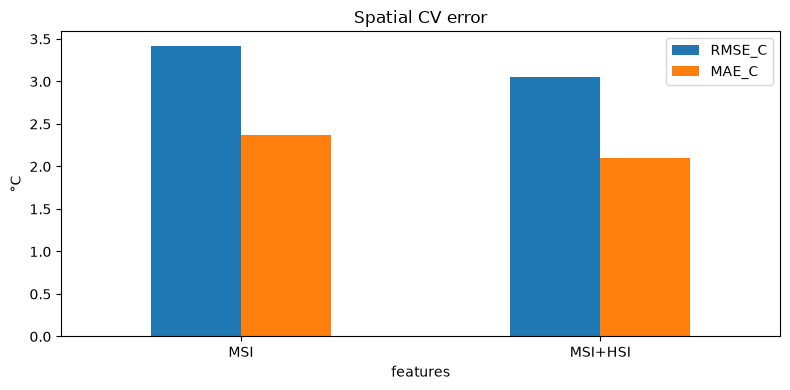

In [14]:
summary_metrics=metrics.groupby("features")[["R2","RMSE_C","MAE_C","Hotspot_F1"]].mean()
delta=pd.Series({
    "Delta_R2":summary_metrics.loc["MSI+HSI","R2"]-summary_metrics.loc["MSI","R2"],
    "RMSE_reduction_C":summary_metrics.loc["MSI","RMSE_C"]-summary_metrics.loc["MSI+HSI","RMSE_C"],
    "Delta_hotspot_F1":summary_metrics.loc["MSI+HSI","Hotspot_F1"]-summary_metrics.loc["MSI","Hotspot_F1"],
})
display(delta.round(3))

ax=summary_metrics[["RMSE_C","MAE_C"]].plot.bar(figsize=(8,4),rot=0,title="Spatial CV error")
ax.set_ylabel("°C"); plt.tight_layout();

## 11. Xuất raster và bảng kết quả

Các raster giữ đúng `EPSG:32648`, transform và kích thước của Tanager. Tệp float dùng `NaN` làm nodata; lớp dùng 255.

In [15]:
def write_float_tif(path,array,descriptions=None):
    data=array[None] if array.ndim==2 else array
    profile=target_profile.copy(); profile.update(driver="GTiff",count=data.shape[0],dtype="float32",nodata=np.nan,compress="deflate",predictor=3)
    with rasterio.open(path,"w",**profile) as dst:
        dst.write(data.astype(np.float32))
        if descriptions: dst.descriptions=tuple(descriptions)

def write_byte_tif(path,array,description):
    profile=target_profile.copy(); profile.update(driver="GTiff",count=1,dtype="uint8",nodata=255,compress="deflate",predictor=2)
    with rasterio.open(path,"w",**profile) as dst:
        dst.write(array.astype(np.uint8),1); dst.set_band_description(1,description)

write_float_tif(OUT_DIR/"tanager_msi_sim.tif",msi,band_names)
write_float_tif(OUT_DIR/"spectral_indices.tif",np.stack([ndvi,ndbi,mndwi]),["NDVI","NDBI","MNDWI"])
write_float_tif(OUT_DIR/"mnf_16.tif",mnf_map,[f"MNF_{i+1}" for i in range(N_MNF)])
write_float_tif(OUT_DIR/"endmember_fractions.tif",fractions,[f"E{i}_fraction" for i in range(N_ENDMEMBERS)])
write_float_tif(OUT_DIR/"landsat_lst_c.tif",lst_c,["LST_C"])
write_float_tif(OUT_DIR/"delta_lst_from_vegetation.tif",delta_lst,["Delta_LST_C"])
write_byte_tif(OUT_DIR/"brazil_four_classes.tif",classes,"Brazil_four_classes")
write_byte_tif(OUT_DIR/"sam_class.tif",sam_class,"SAM_class")
em_table.to_csv(OUT_DIR/"endmember_summary.csv",index=False)
uhi_table.to_csv(OUT_DIR/"uhi_class_summary.csv",index=False)
print("Đã ghi:")
for p in sorted(OUT_DIR.iterdir()): print(" -",p.name)

Đã ghi:
 - brazil_four_classes.tif
 - delta_lst_from_vegetation.tif
 - endmember_fractions.tif
 - endmember_summary.csv
 - landsat_lst_c.tif
 - mnf_16.tif
 - sam_class.tif
 - spatial_cv_metrics.csv
 - spectral_indices.tif
 - tanager_msi_sim.tif
 - uhi_class_summary.csv


## Cách diễn giải kết quả

Kết luận chính dựa trên `Delta_R2`, `RMSE_reduction_C` và `Delta_hotspot_F1`. Nếu MSI+HSI tốt hơn ổn định qua các fold không gian, phổ hẹp mang thông tin bổ sung cho bề mặt nóng. Bản đồ fraction và bảng endmember giúp đặt giả thuyết về asphalt, bê tông, mái kim loại, đất và thực vật; chưa nên báo cáo accuracy vật liệu cho tới khi có polygon kiểm định độc lập.

LST lệch Tanager hai ngày. Phân tích phù hợp cho bề mặt ổn định và proof-of-concept; một nghiên cứu đầy đủ cần thêm nhiều ngày, dữ liệu khí tượng và ground truth vật liệu.